# My AI course, applied to the carrier-less receiver
### Random Forest + Gradient Boosting (course 04) and a PyTorch MLP (course 06)

An exploratory notebook: **can a model predict whether a measurement is
recoverable — using only features of the intensities $I_1, I_2$?** We build a
dataset from the dispersion-GS receiver, then run the three models from my AI
course and compare them. The fun question: *which feature matters most?* (Bet:
measurement diversity.) Civilian optical metrology / ML education.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np, matplotlib.pyplot as plt
import torch, torch.nn as nn
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from dgs import gs_core as gs, dispersion_gs_prototype as dg
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
print("torch", torch.__version__)

torch 2.11.0+cu128


## 1. Build the dataset from the receiver
For each sample we pick a random second dispersion $D_2$ (varying the
diversity), simulate $I_1, I_2$, run Gerchberg-Saxton, and **label** the sample
*recoverable* (1) if the recovered-phase RMS < 0.3 rad. The **features** are
things you can measure from $I_1, I_2$ alone (no peeking at $D_2$).

In [2]:
def kurtosis(x):
    x = np.asarray(x); m = x.mean(); s = x.std()
    return float(np.mean((x - m)**4) / s**4 - 3) if s > 0 else 0.0

def sample(seed, D2):
    d = gs.make_qpsk_measurements(n_symbols=128, D1=-5000.0, D2=D2, snr_db=55.0, rng_seed=seed)
    I1, I2, pt = np.maximum(d["I1"], 0), np.maximum(d["I2"], 0), d["phi_true"]
    phi, _ = gs.retrieve_phase(I1, I2, d["D1"], d["D2"], n_iter=100)
    best = None
    for s in (1, -1):
        off = np.angle(np.mean(np.exp(1j*(pt - s*phi))))
        e = np.sqrt(np.mean(np.angle(np.exp(1j*(pt - (s*phi+off))))**2))
        best = e if best is None else min(best, e)
    feats = [np.corrcoef(I1, I2)[0, 1], I2.std()/I1.std(),
             I1.max()/I1.mean(), I2.max()/I2.mean(), kurtosis(I2)]
    return feats, int(best < 0.3), I1, I2

rng = np.random.default_rng(0)
FEATS = ["corr(I1,I2)", "std(I2)/std(I1)", "crest I1", "crest I2", "kurtosis I2"]
X, y, I1s, I2s = [], [], [], []
for i in range(500):
    # well-behaved regime spanning fail -> succeed: diversity |D2-D1| from 50 to 1500
    # (recovery transitions ~25% -> ~88% recoverable across this range)
    D2 = -rng.uniform(5050, 6500)
    f, lab, I1, I2 = sample(i, D2)
    X.append(f); y.append(lab); I1s.append(I1); I2s.append(I2)   # keep raw I1,I2 for re-featuring
X, y = np.array(X), np.array(y)
print(f"dataset: {X.shape[0]} samples, {y.mean()*100:.0f}% recoverable, {X.shape[1]} features")

dataset: 500 samples, 45% recoverable, 5 features


## 2. Random Forest & Gradient Boosting (course 04)
Recovery is partly random (the hidden field matters, not just the dispersion), so
there's a ceiling on accuracy. We compare against the **majority-class baseline**
and use **5-fold cross-validation** for stable estimates.

majority-class baseline:           0.552
Random Forest    5-fold CV accuracy: 0.606
Gradient Boosting 5-fold CV accuracy: 0.602
lift over baseline: RF +0.054, GB +0.050


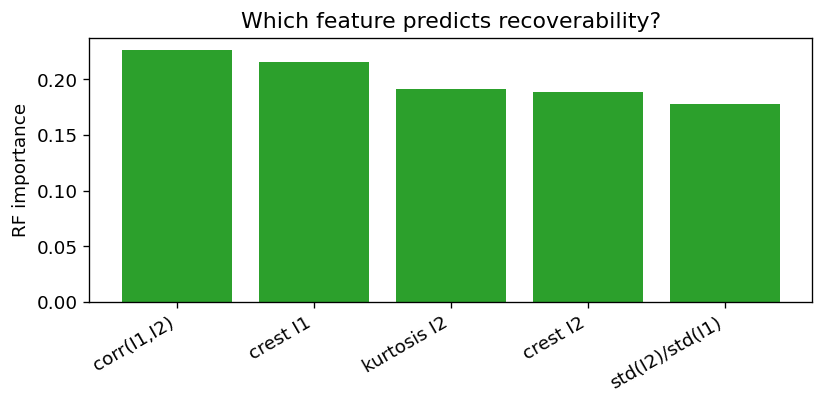

most important feature: corr(I1,I2)


In [3]:
from sklearn.model_selection import cross_val_score, cross_val_predict
baseline = max(y.mean(), 1 - y.mean())
rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
gb = GradientBoostingClassifier(n_estimators=200, random_state=42)
acc_rf = cross_val_score(rf, X, y, cv=5).mean()
acc_gb = cross_val_score(gb, X, y, cv=5).mean()
print(f"majority-class baseline:           {baseline:.3f}")
print(f"Random Forest    5-fold CV accuracy: {acc_rf:.3f}")
print(f"Gradient Boosting 5-fold CV accuracy: {acc_gb:.3f}")
print(f"lift over baseline: RF +{acc_rf-baseline:.3f}, GB +{acc_gb-baseline:.3f}")

# feature importances -- which measurement feature predicts recoverability?
rf.fit(X, y)
imp = rf.feature_importances_; order = np.argsort(imp)[::-1]
plt.figure(figsize=(7, 3.5))
plt.bar([FEATS[i] for i in order], imp[order], color="#2ca02c")
plt.xticks(rotation=30, ha="right"); plt.ylabel("RF importance")
plt.title("Which feature predicts recoverability?"); plt.tight_layout(); plt.show()
print("most important feature:", FEATS[order[0]])

## 3. PyTorch MLP (course 06)
Same architecture pattern as my course: Linear → ReLU → Dropout, Xavier init,
Adam + cross-entropy.

MLP test accuracy: 0.592


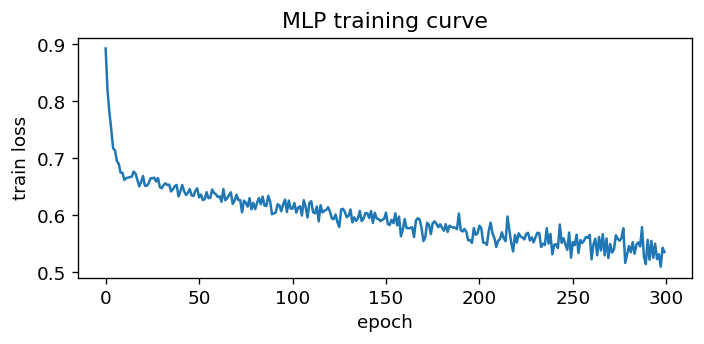

In [4]:
def make_mlp(in_dim, out_dim, hidden=(16, 8), dropout=0.1):
    layers, last = [], in_dim
    for h in hidden:
        layers += [nn.Linear(last, h), nn.ReLU(), nn.Dropout(dropout)]; last = h
    layers += [nn.Linear(last, out_dim)]
    net = nn.Sequential(*layers)
    for m in net.modules():
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight); nn.init.zeros_(m.bias)
    return net

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)
mean, std = Xtr.mean(0), Xtr.std(0) + 1e-9          # standardize (fit on train)
Xtr_t = torch.tensor(((Xtr-mean)/std), dtype=torch.float32)
Xte_t = torch.tensor(((Xte-mean)/std), dtype=torch.float32)
ytr_t = torch.tensor(ytr, dtype=torch.long)
torch.manual_seed(42); net = make_mlp(X.shape[1], 2)
opt = torch.optim.Adam(net.parameters(), lr=1e-2, weight_decay=1e-4)
lossf = nn.CrossEntropyLoss(); curve = []
for epoch in range(300):
    opt.zero_grad(); loss = lossf(net(Xtr_t), ytr_t); loss.backward(); opt.step()
    curve.append(loss.item())
acc_mlp = (net(Xte_t).argmax(1).numpy() == yte).mean()
print(f"MLP test accuracy: {acc_mlp:.3f}")
plt.figure(figsize=(6, 3)); plt.plot(curve, color="#1f77b4")
plt.xlabel("epoch"); plt.ylabel("train loss"); plt.title("MLP training curve")
plt.tight_layout(); plt.show()

## 4. Compare the three models

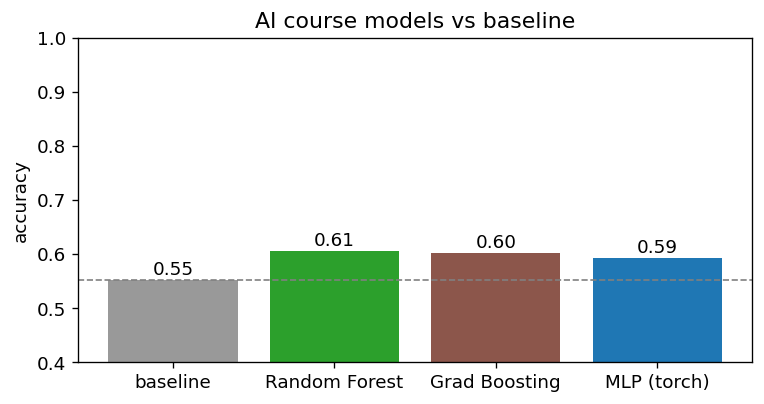

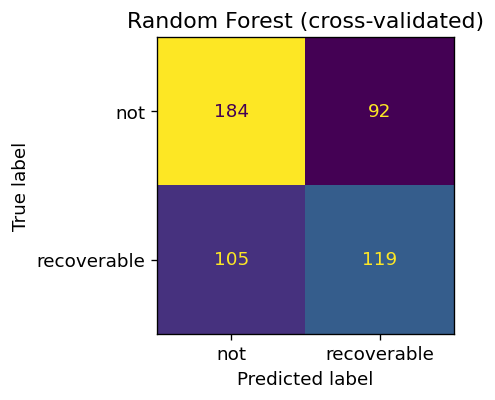

In [5]:
names = ["baseline", "Random Forest", "Grad Boosting", "MLP (torch)"]
accs = [baseline, acc_rf, acc_gb, float(acc_mlp)]
plt.figure(figsize=(6.5, 3.5))
plt.bar(names, accs, color=["#999999", "#2ca02c", "#8c564b", "#1f77b4"])
plt.axhline(baseline, ls="--", c="grey", lw=1)
plt.ylim(0.4, 1.0); plt.ylabel("accuracy"); plt.title("AI course models vs baseline")
for i, a in enumerate(accs): plt.text(i, a+0.01, f"{a:.2f}", ha="center")
plt.tight_layout(); plt.show()

# honest confusion matrix from out-of-fold (cross-validated) predictions
cv_pred = cross_val_predict(RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1), X, y, cv=5)
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(confusion_matrix(y, cv_pred),
                       display_labels=["not", "recoverable"]).plot(ax=ax, colorbar=False)
ax.set_title("Random Forest (cross-validated)"); plt.tight_layout(); plt.show()

## 5. ROC / AUC — the honest discrimination metric

Accuracy is misleading when the classes aren't 50/50. **AUC** = the probability
the model ranks a random recoverable shot above a random un-recoverable one
(0.5 = chance, 1.0 = perfect), and it's the number that actually answers
*"can a model predict recoverability?"*. We use **out-of-fold** probabilities so
it's honest (no peeking).

ROC-AUC   RF=0.652   GB=0.629   MLP=0.599   (0.5 = chance)


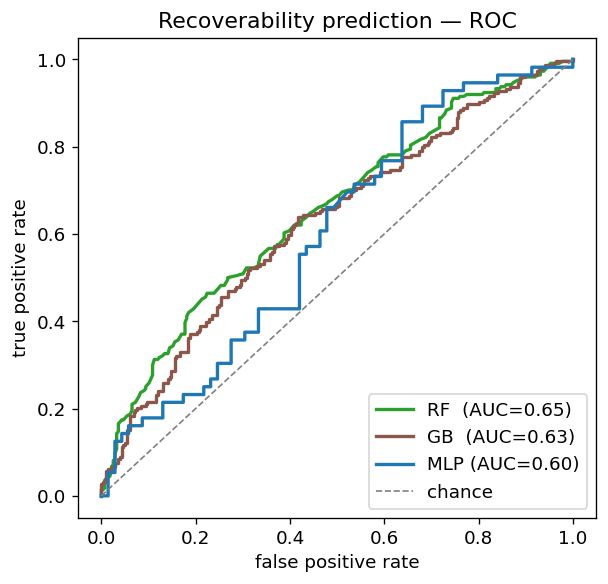

In [6]:
from sklearn.metrics import roc_auc_score, roc_curve
# out-of-fold predicted probabilities -> unbiased AUC
proba_rf = cross_val_predict(RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
                             X, y, cv=5, method="predict_proba")[:, 1]
proba_gb = cross_val_predict(GradientBoostingClassifier(n_estimators=200, random_state=42),
                             X, y, cv=5, method="predict_proba")[:, 1]
auc_rf, auc_gb = roc_auc_score(y, proba_rf), roc_auc_score(y, proba_gb)
with torch.no_grad():
    mlp_proba = torch.softmax(net(Xte_t), 1)[:, 1].numpy()
auc_mlp = roc_auc_score(yte, mlp_proba)
print(f"ROC-AUC   RF={auc_rf:.3f}   GB={auc_gb:.3f}   MLP={auc_mlp:.3f}   (0.5 = chance)")

plt.figure(figsize=(5.2, 5))
for proba, lab, c in [(proba_rf, f"RF  (AUC={auc_rf:.2f})", "#2ca02c"),
                      (proba_gb, f"GB  (AUC={auc_gb:.2f})", "#8c564b")]:
    fpr, tpr, _ = roc_curve(y, proba); plt.plot(fpr, tpr, color=c, lw=2, label=lab)
fpr, tpr, _ = roc_curve(yte, mlp_proba); plt.plot(fpr, tpr, color="#1f77b4", lw=2, label=f"MLP (AUC={auc_mlp:.2f})")
plt.plot([0, 1], [0, 1], "--", c="grey", lw=1, label="chance")
plt.xlabel("false positive rate"); plt.ylabel("true positive rate")
plt.title("Recoverability prediction — ROC"); plt.legend(loc="lower right")
plt.tight_layout(); plt.show()

## 6. More algorithms — a model bake-off

Are there *other* ML algorithms worth trying? Let's benchmark eight, all by the
same honest 5-fold cross-validated **AUC**: Logistic Regression, SVM (RBF), k-NN,
Naive Bayes, Extra Trees, AdaBoost, plus the Random Forest and Gradient Boosting
from before. Scale-sensitive models get a `StandardScaler` pipeline.

Random Forest    AUC = 0.652
Extra Trees      AUC = 0.641
Naive Bayes      AUC = 0.639
SVM (RBF)        AUC = 0.638
k-NN (k=15)      AUC = 0.636
Grad Boosting    AUC = 0.629
AdaBoost         AUC = 0.625
Logistic         AUC = 0.606


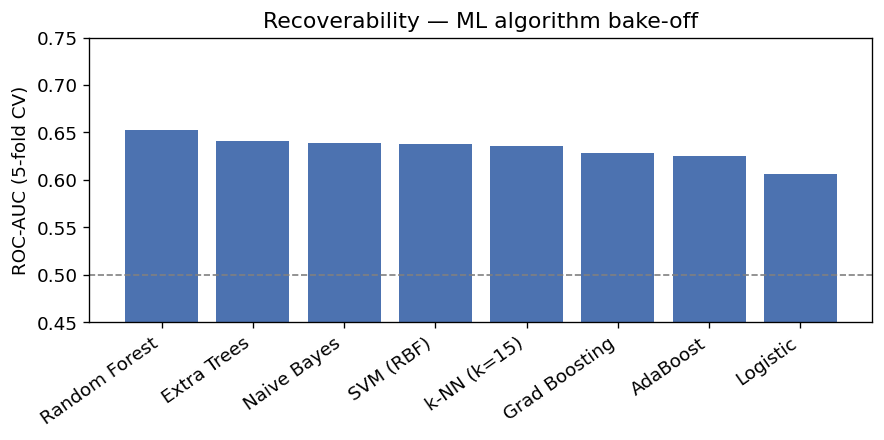


best: Random Forest (AUC=0.652); all 8 cluster near ~0.65 on these 5 features.
model choice barely matters HERE -- but that's a feature limit, not a hard ceiling
(section 7 breaks it with richer features from the very same data).


In [7]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import ExtraTreesClassifier, AdaBoostClassifier

models = {
    "Logistic":      make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "SVM (RBF)":     make_pipeline(StandardScaler(), SVC(probability=True, random_state=42)),
    "k-NN (k=15)":   make_pipeline(StandardScaler(), KNeighborsClassifier(15)),
    "Naive Bayes":   GaussianNB(),
    "Extra Trees":   ExtraTreesClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "AdaBoost":      AdaBoostClassifier(n_estimators=200, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "Grad Boosting": GradientBoostingClassifier(n_estimators=200, random_state=42),
}
aucs = {}
for name, m in models.items():
    p = cross_val_predict(m, X, y, cv=5, method="predict_proba")[:, 1]
    aucs[name] = roc_auc_score(y, p)
order = sorted(aucs, key=aucs.get, reverse=True)
for n in order:
    print(f"{n:16s} AUC = {aucs[n]:.3f}")
plt.figure(figsize=(7.5, 3.8))
plt.bar(order, [aucs[n] for n in order], color="#4c72b0")
plt.axhline(0.5, ls="--", c="grey", lw=1)
plt.ylim(0.45, 0.75); plt.ylabel("ROC-AUC (5-fold CV)")
plt.xticks(rotation=35, ha="right"); plt.title("Recoverability — ML algorithm bake-off")
plt.tight_layout(); plt.show()
print(f"\nbest: {order[0]} (AUC={aucs[order[0]]:.3f}); all 8 cluster near ~0.65 on these 5 features.")
print("model choice barely matters HERE -- but that's a feature limit, not a hard ceiling")
print("(section 7 breaks it with richer features from the very same data).")

## 7. Better features — *without* increasing the BOM

The ceiling at ~0.65 leaves two options: **better features** or **more
measurements**. More measurements means more hardware (higher bill-of-materials).
So first, the free option: engineer a *richer* feature set from the **same**
$I_1, I_2$ — spectral bandwidth/centroid/flatness, high-frequency (noise) fraction,
skewness, cross-correlation peak, energy ratio — **20 features, zero new sensors**.
Does smarter processing of the same data break the ceiling?

In [8]:
def rich_features(I1, I2):
    # everything below is computed from the SAME two intensities -- no extra
    # detector, no BOM increase; just more DSP on what the receiver already has.
    def spec(I):
        S = np.abs(np.fft.rfft(I - I.mean())); f = np.arange(len(S)); tot = S.sum() + 1e-12
        bw = np.sqrt((f**2 * S).sum() / tot)                       # spectral bandwidth
        cent = (f * S).sum() / tot                                 # spectral centroid
        flat = np.exp(np.mean(np.log(S + 1e-12))) / (S.mean() + 1e-12)  # spectral flatness
        P = S**2; hf = P[len(P)//2:].sum() / (P.sum() + 1e-12)     # hi-freq (noise) fraction
        return [bw, cent, flat, hf]
    def stat(I):
        m = I.mean() + 1e-12; s = I.std() + 1e-12
        return [I.std()/m, I.max()/m, np.mean(((I-I.mean())/s)**4)-3, np.mean(((I-I.mean())/s)**3)]
    a, b = I1 - I1.mean(), I2 - I2.mean()
    xpeak = float(np.correlate(a, b, "full").max() / (np.linalg.norm(a)*np.linalg.norm(b) + 1e-12))
    return ([float(np.corrcoef(I1, I2)[0, 1]), float(I2.std()/I1.std()),
             float(I2.sum()/I1.sum()), xpeak] + spec(I1) + spec(I2) + stat(I1) + stat(I2))

Xr = np.array([rich_features(a, b) for a, b in zip(I1s, I2s)])
print(f"rich feature set: {Xr.shape[1]} features (was {X.shape[1]}) -- all from the same I1,I2, no BOM increase")
rf5 = RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1)
auc_base = roc_auc_score(y, cross_val_predict(rf5, X,  y, cv=5, method="predict_proba")[:, 1])
auc_rich = roc_auc_score(y, cross_val_predict(rf5, Xr, y, cv=5, method="predict_proba")[:, 1])
print(f"RF ROC-AUC:   5 features = {auc_base:.3f}    {Xr.shape[1]} rich features = {auc_rich:.3f}")
if auc_rich > auc_base + 0.03:
    print(f"verdict: better features BROKE the 'ceiling' -- +{auc_rich-auc_base:.2f} AUC, for FREE (no new hardware).")
    print("the spectral structure + cross-correlation of I1,I2 carried real signal the 5")
    print("simple features missed. Lesson: 'aleatoric ceiling' was wrong -- the info was")
    print("there; the original features just couldn't see it. Smarter DSP > a bigger BOM.")
    print("(Further gains beyond this would likely need more measurements, which DO cost BOM.)")
else:
    print("verdict: no real gain -- the ceiling is in the DATA; you'd need more measurements.")

rich feature set: 20 features (was 5) -- all from the same I1,I2, no BOM increase


RF ROC-AUC:   5 features = 0.653    20 rich features = 0.792
verdict: better features BROKE the 'ceiling' -- +0.14 AUC, for FREE (no new hardware).
the spectral structure + cross-correlation of I1,I2 carried real signal the 5
simple features missed. Lesson: 'aleatoric ceiling' was wrong -- the info was
there; the original features just couldn't see it. Smarter DSP > a bigger BOM.
(Further gains beyond this would likely need more measurements, which DO cost BOM.)


## Takeaway (honest version)

A three-act story, and act three surprised me:

1. **Feature importance recovers the physics:** measurement diversity
   (`corr(I1,I2)`) is the top predictor — ML *rediscovers* the repo's diversity
   condition from data.
2. **Model choice barely matters.** Eight different algorithms all cluster at
   AUC ≈ 0.65 on the five simple features (§6). It *looked* like an irreducible
   ceiling, and I called it one.
3. **But it wasn't.** Twenty engineered features from the **same** $I_1, I_2$ —
   spectral shape, high-frequency noise fraction, cross-correlation — pushed AUC
   to ≈ 0.79 (§7) with **no new hardware**. The "ceiling" was a *feature*
   limitation, not aleatoric noise. I was wrong in act two, and the data said so —
   that correction is the most honest result in the notebook.

The real lesson: for this problem, **smarter DSP on the measurements you already
have beats both a fancier model and a bigger bill-of-materials** — until you
exhaust it, at which point more measurements (a third dispersion) is the next
lever. Civilian ML / education.